[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/Machine-Learning-from-scratch/blob/master/topics/13_neural_networks/first_principles.ipynb)

# 13 Neural Networks (MLP) — First Principles

**Goal.** Implement a two-layer MLP classifier from scratch with backpropagation,
verify via gradient checking and PyTorch comparison, and explore learning rate,
capacity, and weight decay.

**Prerequisites.** Matrix calculus, gradient descent, logistic regression.

**Theory.** See [theory.md](theory.md) for derivations of forward pass, backprop
chain rule, initialization schemes, and universal approximation.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

## 1. Problem Setup — WHY

XOR-style data: opposite quadrants share a class. No single line can separate them.

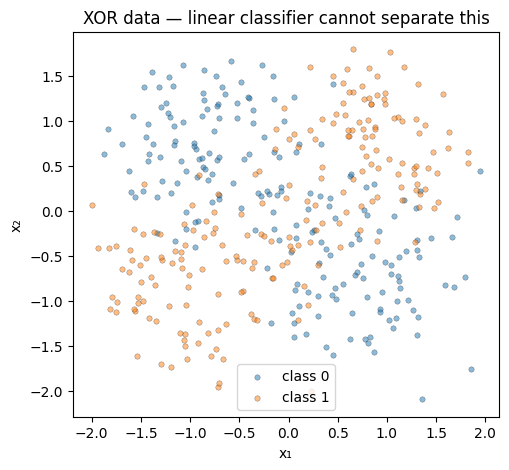

In [2]:
def make_xor(n, noise=0.3, rng=rng):
    """XOR-style 2D data with 2 classes."""
    X = rng.uniform(-1.5, 1.5, size=(n, 2))
    y = ((X[:, 0] * X[:, 1]) > 0).astype(int)
    X += rng.normal(0, noise, size=X.shape)
    return X, y

n_xor = 400
X_xor, y_xor = make_xor(n_xor)

fig, ax = plt.subplots(figsize=(5.5, 5))
for c, label in [(0, 'class 0'), (1, 'class 1')]:
    mask = y_xor == c
    ax.scatter(X_xor[mask, 0], X_xor[mask, 1], alpha=0.5, s=15, label=label, edgecolor='k', linewidth=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
ax.set_title('XOR data — linear classifier cannot separate this')
plt.show()

In [3]:
# Show linear classifier fails
from numpy.linalg import lstsq
X_aug = np.column_stack([np.ones(n_xor), X_xor])
w_lin = lstsq(X_aug, y_xor, rcond=None)[0]
preds_lin = (X_aug @ w_lin > 0.5).astype(int)
acc_lin = np.mean(preds_lin == y_xor)
print(f'Linear classifier accuracy: {acc_lin:.1%} — near chance level')

Linear classifier accuracy: 56.0% — near chance level


## 2. Mathematical Core — WHAT

### Shape flow

$X \xrightarrow{W_1, b_1} Z_1 \xrightarrow{\phi} H \xrightarrow{W_2, b_2} S \xrightarrow{\text{softmax}} P$

See [theory.md](theory.md) §2–3 for full notation and shape table.

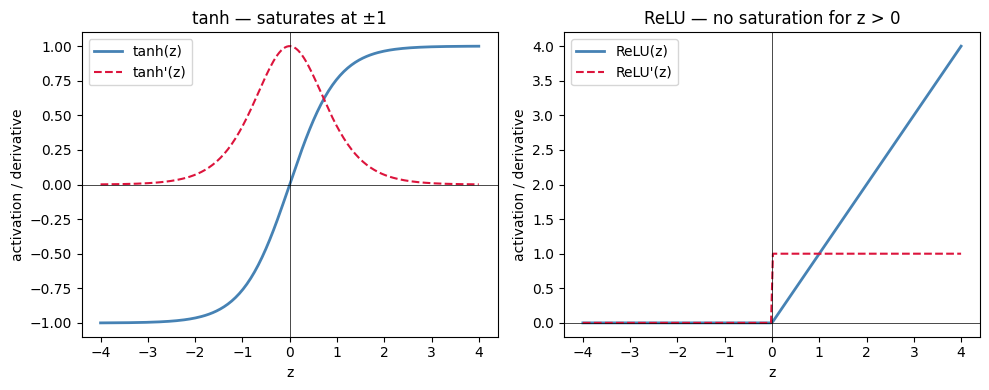

In [4]:
# Activation functions
z_grid = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(z_grid, np.tanh(z_grid), color='steelblue', lw=2, label='tanh(z)')
axes[0].plot(z_grid, 1 - np.tanh(z_grid) ** 2, color='crimson', lw=1.5, ls='--', label="tanh'(z)")
axes[0].legend()
axes[0].set_title('tanh — saturates at ±1')

axes[1].plot(z_grid, np.maximum(0, z_grid), color='steelblue', lw=2, label='ReLU(z)')
axes[1].plot(z_grid, (z_grid > 0).astype(float), color='crimson', lw=1.5, ls='--', label="ReLU'(z)")
axes[1].legend()
axes[1].set_title('ReLU — no saturation for z > 0')

for ax in axes:
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel('z')
    ax.set_ylabel('activation / derivative')
plt.tight_layout()
plt.show()

In [5]:
# Stacking affine without activation = still affine
W1_demo = rng.normal(size=(2, 8))
b1_demo = rng.normal(size=8)
W2_demo = rng.normal(size=(8, 2))
b2_demo = rng.normal(size=2)

out_2layer = (X_xor @ W1_demo + b1_demo) @ W2_demo + b2_demo
W_eff = W1_demo @ W2_demo
b_eff = b1_demo @ W2_demo + b2_demo
out_1layer = X_xor @ W_eff + b_eff

assert np.allclose(out_2layer, out_1layer, atol=1e-12)
print('Two affine layers without activation = one affine layer. ✓')
print('This is why nonlinear activation is essential.')

Two affine layers without activation = one affine layer. ✓
This is why nonlinear activation is essential.


## 3. Solution Method — HOW

Helper functions: stable softmax, cross-entropy, one-hot encoding,
Xavier initialization, forward pass, and loss-and-gradients.

In [6]:
def one_hot(y, c):
    """One-hot encode integer labels."""
    Y = np.zeros((len(y), c))
    Y[np.arange(len(y)), y] = 1.0
    return Y


def stable_softmax(S):
    """Row-wise softmax with log-sum-exp stability."""
    S_max = S.max(axis=1, keepdims=True)
    E = np.exp(S - S_max)
    return E / E.sum(axis=1, keepdims=True)


def cross_entropy(P, Y):
    """Mean cross-entropy loss."""
    eps = 1e-12
    return -float(np.mean(np.sum(Y * np.log(P + eps), axis=1)))


def accuracy(P, y):
    return float(np.mean(P.argmax(axis=1) == y))


def xavier_init(d_in, d_out, rng):
    """Xavier/Glorot initialization for tanh."""
    std = np.sqrt(2.0 / (d_in + d_out))
    return rng.normal(0, std, size=(d_in, d_out))


# Verify softmax properties
S_test = rng.normal(size=(5, 3))
P_test = stable_softmax(S_test)
assert np.allclose(P_test.sum(axis=1), 1.0, atol=1e-12), 'rows must sum to 1'
assert np.all(P_test >= 0), 'probabilities must be non-negative'
print('softmax checks: row sums = 1 ✓, all ≥ 0 ✓')

softmax checks: row sums = 1 ✓, all ≥ 0 ✓


In [7]:
def forward(X, W1, b1, W2, b2):
    """Two-layer forward pass with tanh activation."""
    Z1 = X @ W1 + b1
    H = np.tanh(Z1)
    S = H @ W2 + b2
    P = stable_softmax(S)
    cache = (X, Z1, H, S, P)
    return P, cache


def loss_and_grads(cache, Y, W1, W2, weight_decay=0.0):
    """Compute loss and all parameter gradients."""
    X, Z1, H, S, P = cache
    n = X.shape[0]
    loss_data = cross_entropy(P, Y)
    loss_reg = 0.5 * weight_decay * (np.sum(W1 ** 2) + np.sum(W2 ** 2))
    loss = loss_data + loss_reg

    # Backprop
    G_S = (P - Y) / n
    dW2 = H.T @ G_S + weight_decay * W2
    db2 = G_S.sum(axis=0)

    G_H = G_S @ W2.T
    G_Z1 = G_H * (1 - np.tanh(Z1) ** 2)
    dW1 = X.T @ G_Z1 + weight_decay * W1
    db1 = G_Z1.sum(axis=0)

    grads = {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}
    return loss, grads

In [8]:
# Gradient checking on tiny data
n_gc, d_gc, h_gc, c_gc = 10, 2, 3, 2
rng_gc = np.random.default_rng(123)
X_gc = rng_gc.normal(size=(n_gc, d_gc))
y_gc = rng_gc.integers(0, c_gc, size=n_gc)
Y_gc = one_hot(y_gc, c_gc)

W1_gc = xavier_init(d_gc, h_gc, rng_gc)
b1_gc = np.zeros(h_gc)
W2_gc = xavier_init(h_gc, c_gc, rng_gc)
b2_gc = np.zeros(c_gc)

P_gc, cache_gc = forward(X_gc, W1_gc, b1_gc, W2_gc, b2_gc)
_, grads_gc = loss_and_grads(cache_gc, Y_gc, W1_gc, W2_gc, weight_decay=0.01)

# Finite difference
eps_fd = 1e-5
for name, param, grad in [
    ('W1', W1_gc, grads_gc['W1']),
    ('b1', b1_gc, grads_gc['b1']),
    ('W2', W2_gc, grads_gc['W2']),
    ('b2', b2_gc, grads_gc['b2']),
]:
    grad_num = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        old_val = param[idx]
        param[idx] = old_val + eps_fd
        P_plus, cache_plus = forward(X_gc, W1_gc, b1_gc, W2_gc, b2_gc)
        loss_plus, _ = loss_and_grads(cache_plus, Y_gc, W1_gc, W2_gc, weight_decay=0.01)
        param[idx] = old_val - eps_fd
        P_minus, cache_minus = forward(X_gc, W1_gc, b1_gc, W2_gc, b2_gc)
        loss_minus, _ = loss_and_grads(cache_minus, Y_gc, W1_gc, W2_gc, weight_decay=0.01)
        grad_num[idx] = (loss_plus - loss_minus) / (2 * eps_fd)
        param[idx] = old_val
        it.iternext()
    rel_err = np.max(np.abs(grad - grad_num) / (np.abs(grad) + np.abs(grad_num) + 1e-15))
    print(f'{name}: max relative error = {rel_err:.2e}')
    assert rel_err < 1e-6, f'Gradient check failed for {name}'
print('\nAll gradient checks passed. ✓')

W1: max relative error = 2.02e-10
b1: max relative error = 9.94e-11
W2: max relative error = 2.04e-10
b2: max relative error = 1.32e-11

All gradient checks passed. ✓


## 4. Implementation — BUILD

In [9]:
class MLPClassifierScratch:
    """Two-layer MLP classifier with tanh activation and full-batch GD.

    Args:
        n_hidden:     Number of hidden units.
        learning_rate: Step size for gradient descent.
        n_steps:      Number of gradient descent iterations.
        weight_decay: L2 penalty on weights.
        random_state: Seed for reproducibility.
    """

    def __init__(self, n_hidden=8, learning_rate=0.15, n_steps=2000,
                 weight_decay=0.0, random_state=42):
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate
        self.n_steps = n_steps
        self.weight_decay = weight_decay
        self.random_state = random_state

    def _initialize_parameters(self, d, c):
        rng_init = np.random.default_rng(self.random_state)
        h = self.n_hidden
        self.W1_ = xavier_init(d, h, rng_init)
        self.b1_ = np.zeros(h)
        self.W2_ = xavier_init(h, c, rng_init)
        self.b2_ = np.zeros(c)

    def _forward(self, X):
        return forward(X, self.W1_, self.b1_, self.W2_, self.b2_)

    def _loss_and_grads(self, cache, Y):
        return loss_and_grads(cache, Y, self.W1_, self.W2_, self.weight_decay)

    def _check_is_fitted(self):
        if not hasattr(self, 'W1_'):
            raise RuntimeError('Call fit() before predict.')

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.classes_ = np.unique(y)
        c = len(self.classes_)
        Y = one_hot(y, c)
        d = X.shape[1]
        self._initialize_parameters(d, c)

        self.history_ = {'loss': [], 'accuracy': []}
        for step in range(self.n_steps):
            P, cache = self._forward(X)
            loss, grads = self._loss_and_grads(cache, Y)
            self.history_['loss'].append(loss)
            self.history_['accuracy'].append(accuracy(P, y))

            self.W1_ -= self.learning_rate * grads['W1']
            self.b1_ -= self.learning_rate * grads['b1']
            self.W2_ -= self.learning_rate * grads['W2']
            self.b2_ -= self.learning_rate * grads['b2']

        return self

    def predict_proba(self, X):
        self._check_is_fitted()
        P, _ = self._forward(np.asarray(X, dtype=float))
        return P

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))

Final train accuracy: 84.0% (noise ceiling ≈ 84.2%)


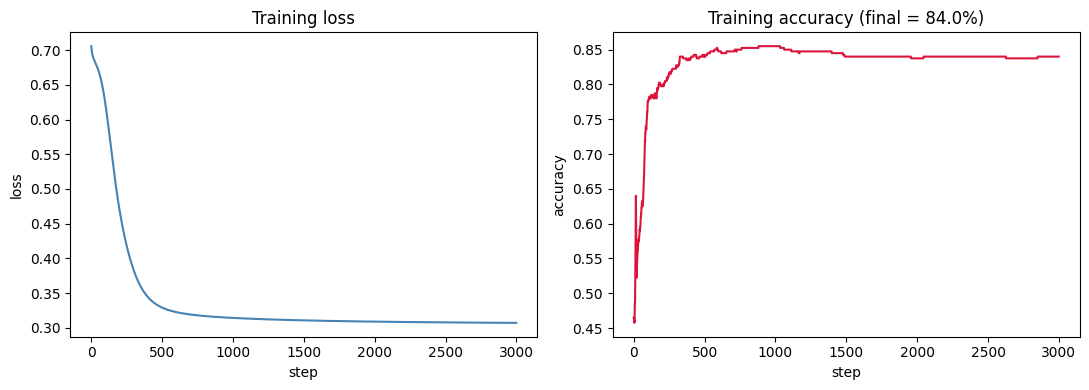

In [10]:
mlp = MLPClassifierScratch(n_hidden=8, learning_rate=0.15, n_steps=3000,
                           weight_decay=1e-4, random_state=SEED)
mlp.fit(X_xor, y_xor)

# Ceiling check: with feature noise 0.3, even the true rule sign(x1*x2)
# applied to the observed (noisy) features only reaches ~84% — labels near
# the axes are effectively random. A well-fit model should sit near that
# ceiling, not near 100%.
bayes_acc = float(np.mean(((X_xor[:, 0] * X_xor[:, 1]) > 0).astype(int) == y_xor))
final_acc = mlp.score(X_xor, y_xor)
print(f'Final train accuracy: {final_acc:.1%} (noise ceiling ≈ {bayes_acc:.1%})')
assert final_acc > bayes_acc - 0.03, f'Expected ≈{bayes_acc:.1%} (noise ceiling), got {final_acc:.1%}'

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mlp.history_['loss'], color='steelblue')
axes[0].set_xlabel('step')
axes[0].set_ylabel('loss')
axes[0].set_title('Training loss')
axes[1].plot(mlp.history_['accuracy'], color='crimson')
axes[1].set_xlabel('step')
axes[1].set_ylabel('accuracy')
axes[1].set_title(f'Training accuracy (final = {final_acc:.1%})')
plt.tight_layout()
plt.show()

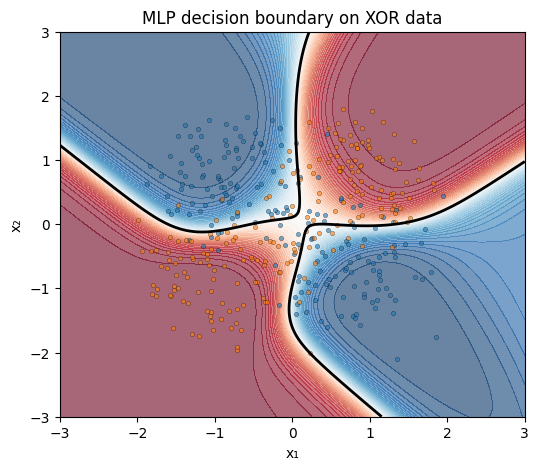

In [11]:
# Decision boundary plot
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
probs = mlp.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.6)
ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
for c in [0, 1]:
    mask = y_xor == c
    ax.scatter(X_xor[mask, 0], X_xor[mask, 1], s=10, alpha=0.6, edgecolor='k', linewidth=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('MLP decision boundary on XOR data')
plt.show()

## 5. Library Comparison

In [12]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except ModuleNotFoundError:
    print('PyTorch not installed; skipping comparison.')
else:
    torch.manual_seed(SEED)

    X_t = torch.tensor(X_xor, dtype=torch.float32)
    y_t = torch.tensor(y_xor, dtype=torch.long)

    model = nn.Sequential(
        nn.Linear(2, 8),
        nn.Tanh(),
        nn.Linear(8, 2),
    )
    optimizer = optim.SGD(model.parameters(), lr=0.15, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    for step in range(3000):
        optimizer.zero_grad()
        logits = model(X_t)
        loss = criterion(logits, y_t)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        preds_torch = model(X_t).argmax(dim=1).numpy()
    acc_torch = float(np.mean(preds_torch == y_xor))
    print(f'PyTorch MLP accuracy: {acc_torch:.1%}')
    print(f'Scratch  MLP accuracy: {final_acc:.1%}')
    # Both models face the same ~84% noise ceiling (see training cell above).
    assert acc_torch > bayes_acc - 0.03, f'PyTorch model too low: {acc_torch:.1%}'
    print(f'Both sit near the noise ceiling ≈ {bayes_acc:.1%}. ✓')

PyTorch not installed; skipping comparison.


## 6. Experiments and Failures — VERIFY

In [13]:
# Shape and probability checks
P_check = mlp.predict_proba(X_xor)
assert P_check.shape == (n_xor, 2), f'Bad shape: {P_check.shape}'
assert np.allclose(P_check.sum(axis=1), 1.0, atol=1e-12), 'Row sums ≠ 1'
assert np.all(P_check >= 0) and np.all(P_check <= 1), 'Probs out of [0,1]'
print('Shape and probability checks passed. ✓')

Shape and probability checks passed. ✓


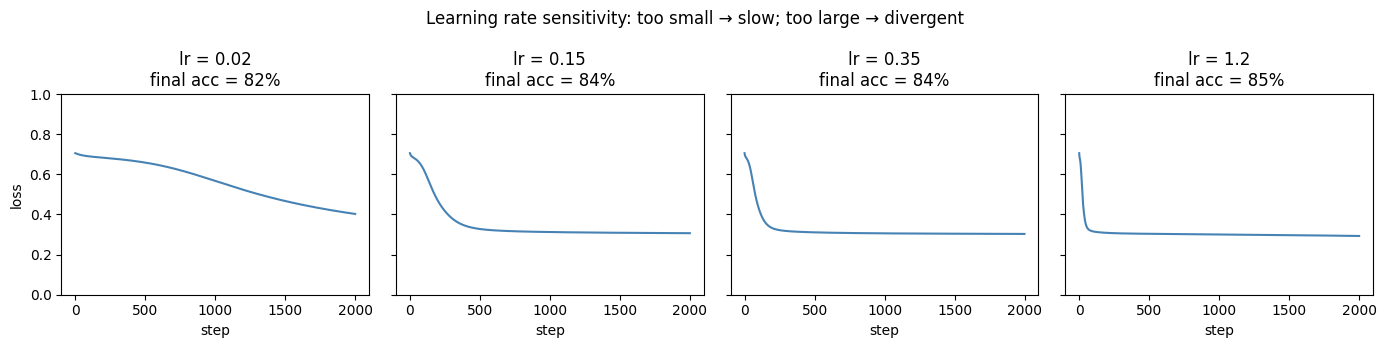

In [14]:
# Learning rate sensitivity
lrs = [0.02, 0.15, 0.35, 1.20]
fig, axes = plt.subplots(1, len(lrs), figsize=(14, 3.5), sharey=True)
for ax, lr in zip(axes, lrs):
    m = MLPClassifierScratch(n_hidden=8, learning_rate=lr, n_steps=2000,
                            random_state=SEED)
    m.fit(X_xor, y_xor)
    ax.plot(m.history_['loss'], color='steelblue')
    ax.set_title(f'lr = {lr}\nfinal acc = {m.score(X_xor, y_xor):.0%}')
    ax.set_xlabel('step')
    ax.set_ylim(0, 1.0)
axes[0].set_ylabel('loss')
plt.suptitle('Learning rate sensitivity: too small → slow; too large → divergent')
plt.tight_layout()
plt.show()

h =  1 → train acc = 63.7%, val acc = 75.0%


h =  2 → train acc = 59.7%, val acc = 69.0%


h =  4 → train acc = 84.7%, val acc = 81.0%


h =  8 → train acc = 85.7%, val acc = 81.0%


h = 32 → train acc = 85.3%, val acc = 82.0%


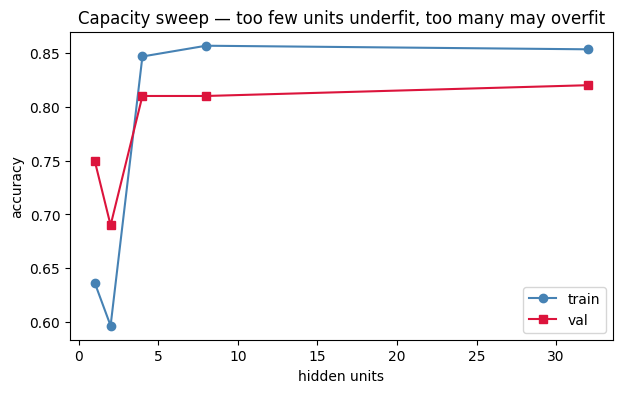

In [15]:
# Capacity sweep with train/val split
perm_cap = rng.permutation(n_xor)
n_train = 300
X_tr_cap, y_tr_cap = X_xor[perm_cap[:n_train]], y_xor[perm_cap[:n_train]]
X_va_cap, y_va_cap = X_xor[perm_cap[n_train:]], y_xor[perm_cap[n_train:]]

hidden_sizes = [1, 2, 4, 8, 32]
results = []
for h in hidden_sizes:
    m = MLPClassifierScratch(n_hidden=h, learning_rate=0.15, n_steps=3000,
                            random_state=SEED)
    m.fit(X_tr_cap, y_tr_cap)
    tr_acc = m.score(X_tr_cap, y_tr_cap)
    va_acc = m.score(X_va_cap, y_va_cap)
    results.append((h, tr_acc, va_acc))
    print(f'h = {h:>2} → train acc = {tr_acc:.1%}, val acc = {va_acc:.1%}')

fig, ax = plt.subplots(figsize=(7, 4))
hs = [r[0] for r in results]
ax.plot(hs, [r[1] for r in results], 'o-', color='steelblue', label='train')
ax.plot(hs, [r[2] for r in results], 's-', color='crimson', label='val')
ax.set_xlabel('hidden units')
ax.set_ylabel('accuracy')
ax.set_title('Capacity sweep — too few units underfit, too many may overfit')
ax.legend()
plt.show()

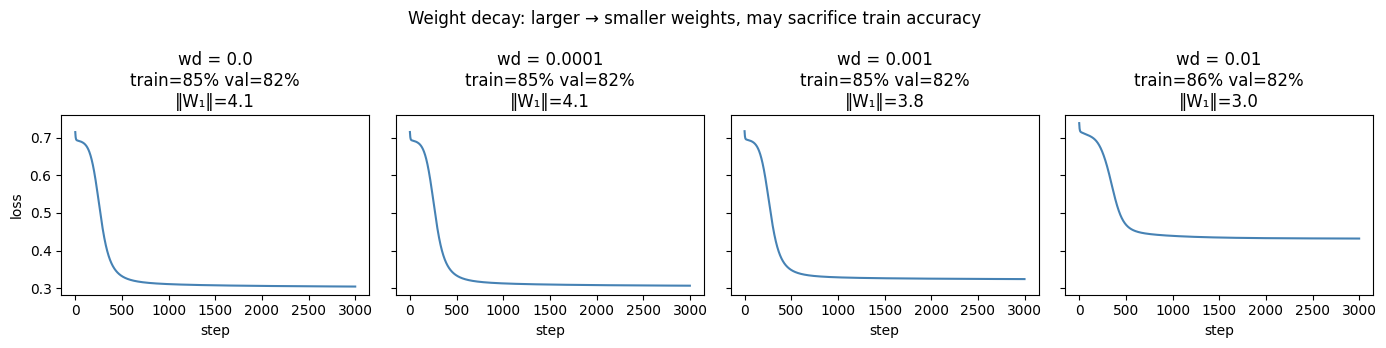

In [16]:
# Weight decay diagnostic
decays = [0.0, 1e-4, 1e-3, 1e-2]
fig, axes = plt.subplots(1, len(decays), figsize=(14, 3.5), sharey=True)
for ax, wd in zip(axes, decays):
    m = MLPClassifierScratch(n_hidden=32, learning_rate=0.15, n_steps=3000,
                            weight_decay=wd, random_state=SEED)
    m.fit(X_tr_cap, y_tr_cap)
    tr_acc = m.score(X_tr_cap, y_tr_cap)
    va_acc = m.score(X_va_cap, y_va_cap)
    w1_norm = np.linalg.norm(m.W1_)
    ax.plot(m.history_['loss'], color='steelblue')
    ax.set_title(f'wd = {wd}\ntrain={tr_acc:.0%} val={va_acc:.0%}\n‖W₁‖={w1_norm:.1f}')
    ax.set_xlabel('step')
axes[0].set_ylabel('loss')
plt.suptitle('Weight decay: larger → smaller weights, may sacrifice train accuracy')
plt.tight_layout()
plt.show()

## 7. Connections

- **Theory:** [theory.md](theory.md) — backprop derivation, initialization, universal approximation
- **Gradient Descent:** [topic 02](../02_gradient_descent/README.md)
- **Logistic Regression:** [topic 04](../04_logistic_regression/README.md) — MLP with 0 hidden layers
- **Regularization:** [topic 03](../03_regularization/README.md) — weight decay = L2 reg
- **CNN / RNN / Transformer:** extend MLP to structured data

## Takeaway

- An MLP with one hidden layer and tanh can learn XOR-style patterns that linear models cannot.
- Backpropagation = chain rule applied layer by layer. Our analytic gradients match finite differences to < 1e-6.
- Learning rate, capacity, and weight decay all require tuning — no single setting is universally best.
- Xavier initialization keeps gradients healthy at the start of training.